# Task 1:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize


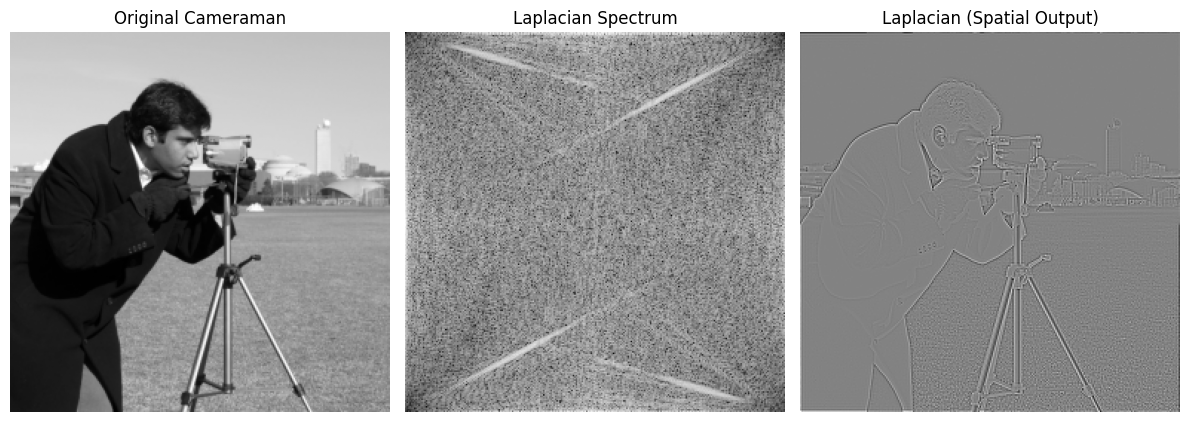

In [ ]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256)) # Resize for faster FFT (optional)
# Get image size
M, N = image.shape
# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)
# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)
# Apply 2D FFT
F = np.fft.fft2(image)
# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter
# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real
# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
sobel_x = np.array([[-1, 0, 1],
[-2, 0, 2],
[-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],
[ 0, 0, 0],
[ 1, 2, 1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded)) # Shift before FFT to place (0,0)at top-left

In [8]:
F_img = np.fft.fft2(image)
F_sobel_x = center_embed_kernel(sobel_x, image.shape)
F_sobel_y = center_embed_kernel(sobel_y, image.shape)

In [9]:
Gx = F_img * F_sobel_x
Gy = F_img * F_sobel_y

gx = np.real(np.fft.ifft2(Gx))
gy = np.real(np.fft.ifft2(Gy))

gradient_magnitude = np.sqrt(gx**2 + gy**2)

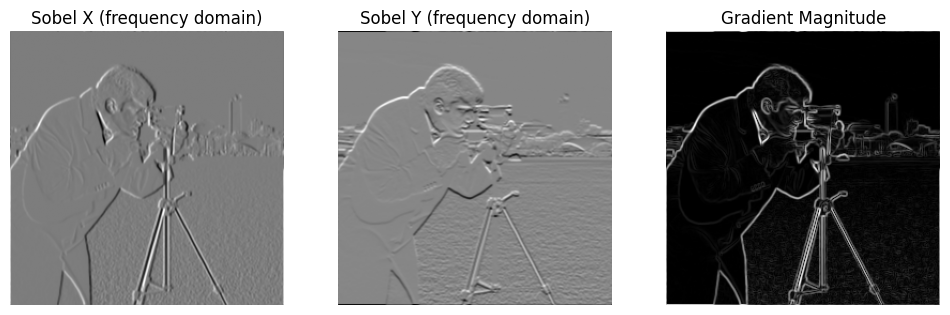

In [10]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(gx, cmap='gray')
plt.title('Sobel X (frequency domain)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gy, cmap='gray')
plt.title('Sobel Y (frequency domain)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.show()